# Mercedes-Benz Greener Manufacturing — EDA & Preprocessing

**Objective:** Explore and prepare the Mercedes-Benz dataset for predictive modeling of testing time (`y`).  
The downstream goal is to use SHAP values to identify which anonymized processes most influence testing duration, enabling managerial recommendations for efficiency improvements.

**Notebook Outline:**
1. Setup & Data Loading
2. High-Level Data Overview
3. Target Variable (`y`) Analysis
4. Categorical Feature Exploration
5. Binary Feature Analysis
6. Correlation & Multicollinearity
7. Feature Interactions & Clustering
8. One-Hot Encoding & Final Preprocessing
9. Export Clean Dataset for Modeling

---
## 1. Setup & Data Loading

In [14]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Clustering
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold

# Stats
from scipy import stats

# Settings
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

%matplotlib inline

print('All imports loaded.')

All imports loaded.


In [15]:
# ── Load data ──────────────────────────────────────────────────────
# Download train.csv and test.csv from Kaggle and place them in the
# same directory as this notebook (or adjust paths below).

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train shape: {train.shape}')
print(f'Test  shape: {test.shape}')

Train shape: (4209, 378)
Test  shape: (4209, 377)


---
## 2. High-Level Data Overview

In [16]:
train.head(10)

,ID,y,X0,X1,X2,X3,X4,X5,X6,X8,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,...,X360,X361,X362,X363,X364,X365,X366,X367,X368,X369,X370,X371,X372,X373,X374,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,0,130.81,k,v,at,a,d,u,j,o,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,6,88.53,k,t,av,e,d,y,l,o,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,7,76.26,az,w,n,c,d,x,j,x,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,9,80.62,az,t,n,f,d,x,l,e,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,13,78.02,az,v,n,f,d,h,d,n,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
5,18,92.93,t,b,e,c,d,g,h,s,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
6,24,128.76,al,r,e,f,d,f,h,s,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
7,25,91.91,o,l,as,f,d,f,j,a,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
8,27,108.67,w,s,as,e,d,f,i,h,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
9,30,126.99,j,b,aq,c,d,f,a,e,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [17]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4209 entries, 0 to 4208
Columns: 378 entries, ID to X385
dtypes: float64(1), int64(369), str(8)
memory usage: 12.1 MB


In [18]:
# Identify column types
cat_cols = train.select_dtypes(include='object').columns.tolist()
num_cols = train.select_dtypes(include='number').columns.tolist()

# Separate the binary (0/1) features from the ID and target
binary_cols = [c for c in num_cols if c not in ['ID', 'y'] and train[c].nunique() <= 2]

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Binary feature columns: {len(binary_cols)}')
print(f'Total numeric columns (incl ID, y): {len(num_cols)}')

Categorical columns (8): ['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X8']
Binary feature columns: 368
Total numeric columns (incl ID, y): 370


/var/folders/jr/0m1f9xgx6_j43mx32cyrtnpr0000gn/T/ipykernel_45959/3874053538.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns.tolist()


In [19]:
# Missing values
missing = train.isnull().sum()
print('Columns with missing values:', missing[missing > 0].shape[0])
missing[missing > 0]

Columns with missing values: 0


Series([], dtype: int64)

In [20]:
# Quick descriptive statistics for target + a sample of binary cols
train[['y'] + binary_cols[:10]].describe()

,y,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19
count,4209.000000,4209.000000,4209.0,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000
mean,100.669318,0.013305,0.0,0.075077,0.057971,0.428130,0.000475,0.002613,0.007603,0.007840,0.099549
std,12.679381,0.114590,0.0,0.263547,0.233716,0.494867,0.021796,0.051061,0.086872,0.088208,0.299433
min,72.110000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,90.820000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,99.150000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,109.010000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,265.320000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


---
## 3. Target Variable (`y`) Analysis

`y` represents the time (in seconds) a car spends on the test bench. Understanding its distribution is critical before modeling.

In [21]:
print(train['y'].describe())
print(f"\nSkewness : {train['y'].skew():.3f}")
print(f"Kurtosis : {train['y'].kurtosis():.3f}")

count    4209.000000
mean      100.669318
std        12.679381
min        72.110000
25%        90.820000
50%        99.150000
75%       109.010000
max       265.320000
Name: y, dtype: float64

Skewness : 1.207
Kurtosis : 7.911


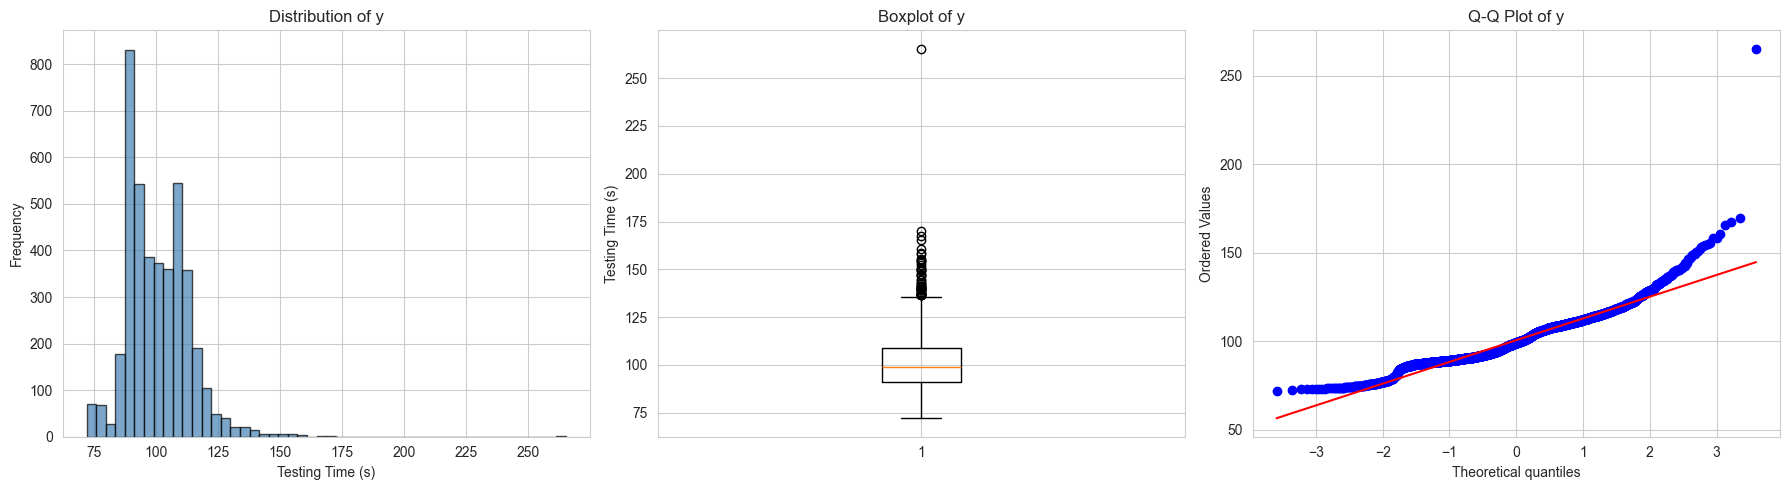

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(train['y'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribution of y')
axes[0].set_xlabel('Testing Time (s)')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(train['y'], vert=True)
axes[1].set_title('Boxplot of y')
axes[1].set_ylabel('Testing Time (s)')

# QQ plot
stats.probplot(train['y'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of y')

plt.tight_layout()
plt.show()

In [23]:
# Check for extreme outliers (IQR method)
Q1, Q3 = train['y'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = train[(train['y'] < lower) | (train['y'] > upper)]
print(f'IQR bounds: [{lower:.2f}, {upper:.2f}]')
print(f'Outlier rows: {len(outliers)} ({100*len(outliers)/len(train):.1f}%)')
print(f'Max y value: {train["y"].max():.2f}')
train = train[train['y'] != train['y'].max()].reset_index(drop=True)

# NOTE: Decide later whether to cap / remove outliers before modeling.
# For SHAP-based insight work, keeping outliers may be informative.

IQR bounds: [63.53, 136.30]
Outlier rows: 50 (1.2%)
Max y value: 265.32


---
## 4. Categorical Feature Exploration

The dataset has a handful of categorical columns (X0 – X8, though not all may be present). These represent different car configuration options.

In [24]:
for col in cat_cols:
    n_train = train[col].nunique()
    n_test  = test[col].nunique()
    unseen  = set(test[col].unique()) - set(train[col].unique())
    print(f'{col}: {n_train} train levels, {n_test} test levels, '
          f'{len(unseen)} unseen in test → {unseen if unseen else "none"}')

X0: 47 train levels, 49 test levels, 6 unseen in test → {'p', 'ag', 'bb', 'av', 'an', 'ae'}
X1: 27 train levels, 27 test levels, 0 unseen in test → none
X2: 43 train levels, 45 test levels, 6 unseen in test → {'ad', 'aj', 'u', 'ax', 'ab', 'w'}
X3: 7 train levels, 7 test levels, 0 unseen in test → none
X4: 4 train levels, 4 test levels, 0 unseen in test → none
X5: 29 train levels, 32 test levels, 4 unseen in test → {'a', 'b', 't', 'z'}
X6: 12 train levels, 12 test levels, 0 unseen in test → none
X8: 25 train levels, 25 test levels, 0 unseen in test → none


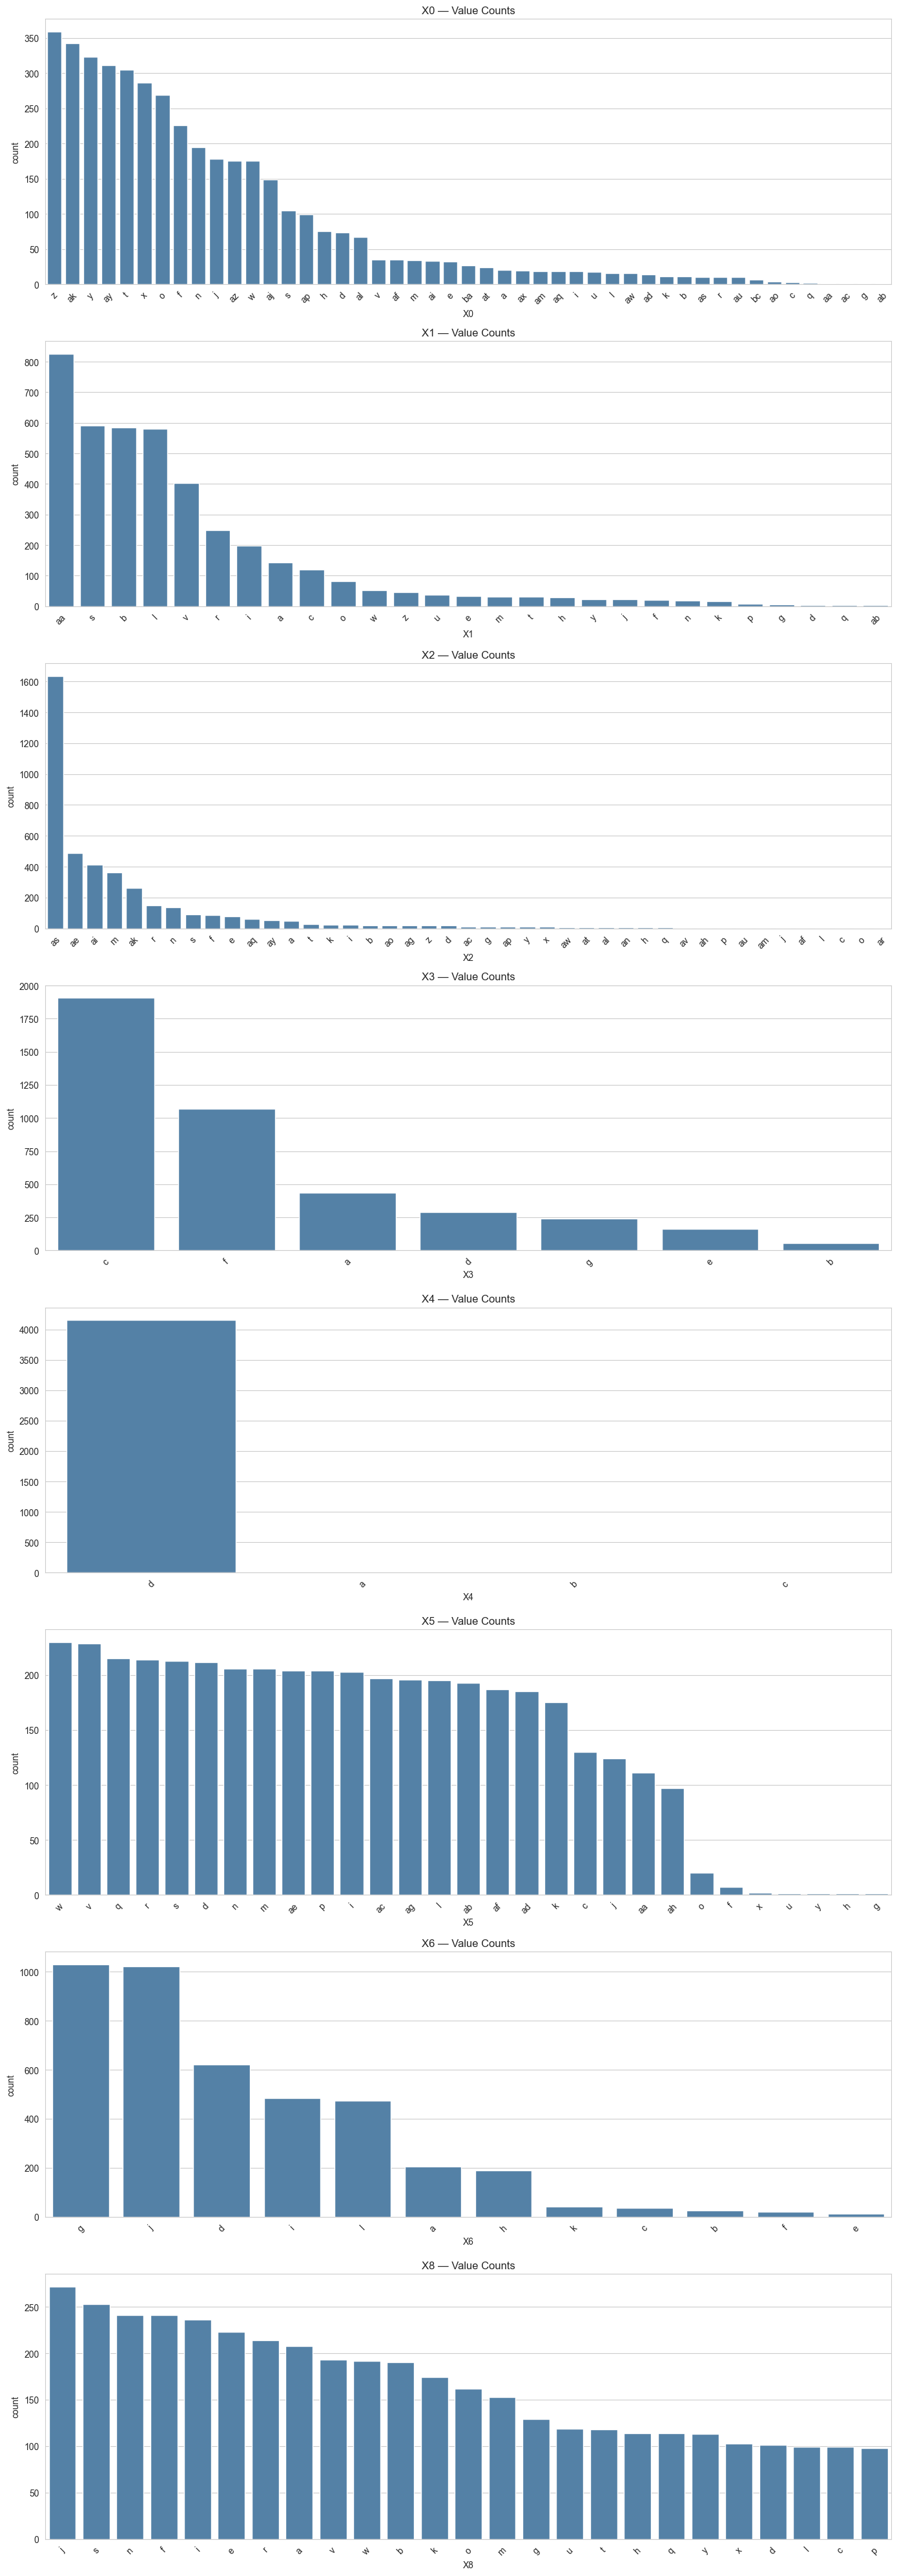

In [25]:
# Value counts for each categorical feature
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(14, 5 * len(cat_cols)))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    order = train[col].value_counts().index
    sns.countplot(data=train, x=col, order=order, ax=ax, color='steelblue')
    ax.set_title(f'{col} — Value Counts')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [26]:
# Mean y by categorical level — which configurations lead to longer testing?
for col in cat_cols:
    agg = (train.groupby(col)['y']
           .agg(['mean', 'median', 'std', 'count'])
           .sort_values('mean', ascending=False))
    print(f'\n── {col} ──')
    display(agg.head(15))


── X0 ──


,mean,median,std,count
X0,,,,
aa,134.430000,134.430,NaN,1
au,115.935000,115.435,5.162362,10
ap,115.592929,114.630,4.925427,99
as,115.349000,113.645,5.943890,10
a,114.277000,112.610,5.057135,20
r,113.914000,113.140,3.902339,10
af,112.791143,112.750,6.258104,35
at,112.314167,110.940,5.366952,24
ab,112.300000,112.300,NaN,1



── X1 ──


,mean,median,std,count
X1,,,,
e,107.337879,107.610,10.489810,33
k,106.800000,107.450,8.622795,17
p,105.568889,108.210,10.246085,9
i,104.723283,105.235,8.895333,198
h,103.672759,106.020,15.437541,29
g,103.191667,105.290,10.993881,6
m,102.788750,107.785,15.834829,32
j,102.489545,101.900,8.928187,22
s,101.345542,101.910,11.543081,590



── X2 ──


...

,mean,median,std,count
X5,,,,
u,130.810000,130.810,NaN,1
f,105.594286,102.090,17.258377,7
c,101.994077,101.290,12.486655,130
ad,101.493189,101.130,12.550206,185
n,101.489854,99.830,13.000463,206
ab,101.448238,100.500,11.561683,193
m,101.243058,100.450,11.825533,206
af,101.037112,100.590,11.333246,187
ae,100.688480,99.655,11.426015,204



── X6 ──


,mean,median,std,count
X6,,,,
e,109.751667,109.845,10.483788,12
h,102.687713,102.275,12.057933,188
d,101.047617,100.240,10.600654,621
i,100.840228,99.690,11.228967,483
k,100.730714,102.895,11.550041,42
c,100.707500,101.920,12.012691,36
j,100.454883,99.845,11.860352,1022
g,99.721485,98.165,11.524402,1030
l,98.224397,97.510,10.557556,473



── X8 ──


,mean,median,std,count
X8,,,,
e,104.566951,107.380,10.780675,223
i,102.970000,104.930,10.805876,236
r,102.602196,103.850,11.780987,214
h,102.535175,104.960,11.766742,114
n,102.011203,102.910,13.335308,241
v,101.732124,100.040,11.116891,193
q,101.477105,100.305,10.764548,114
u,101.156723,99.740,10.487951,119
y,100.359292,99.930,10.452048,113


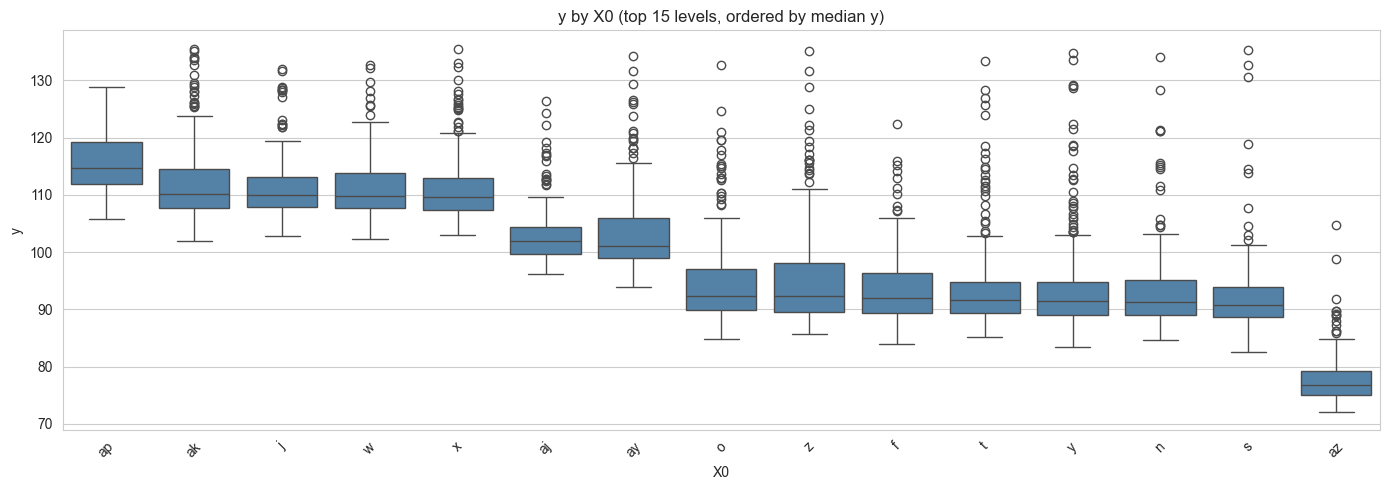

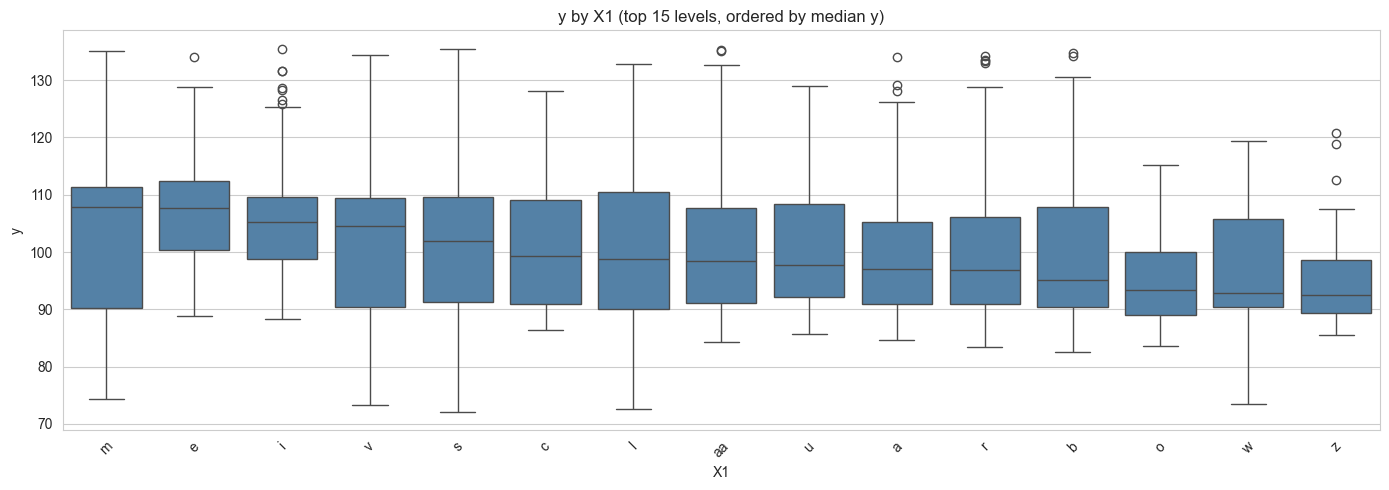

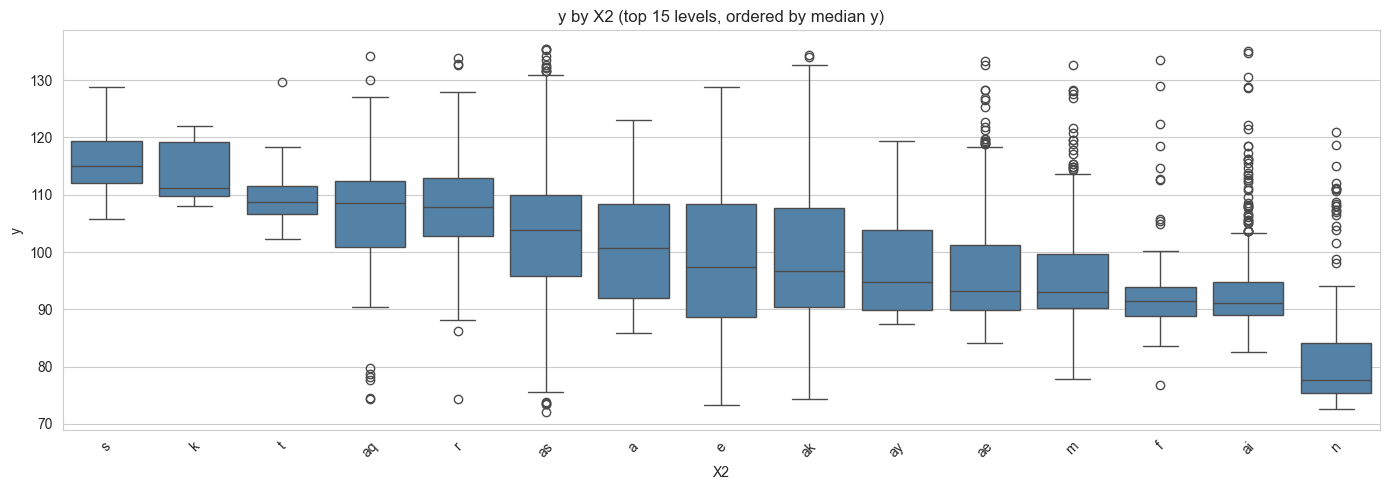

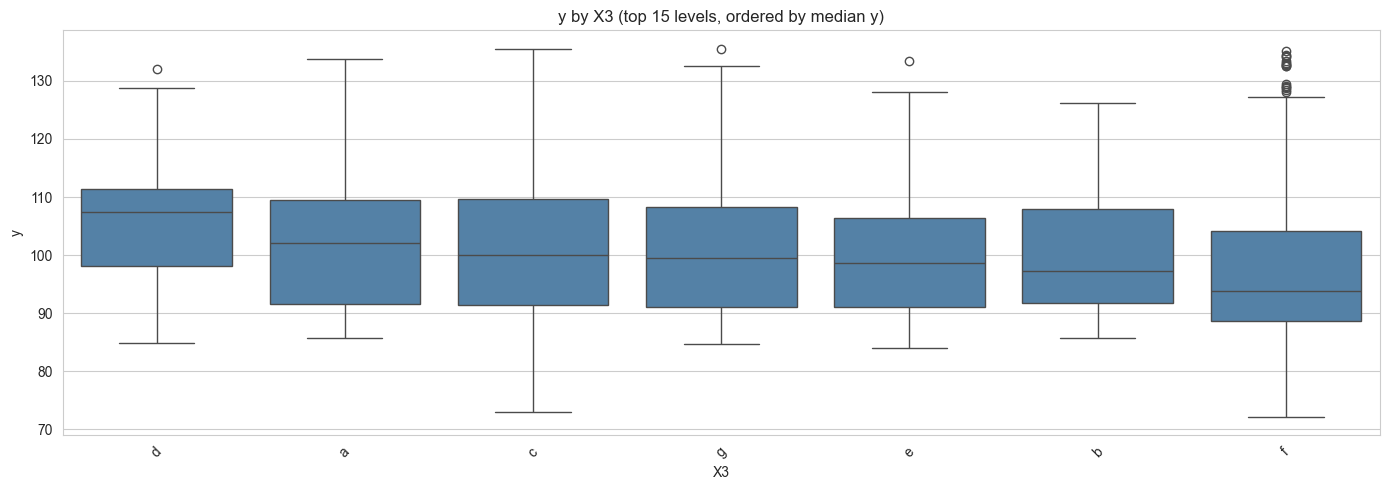

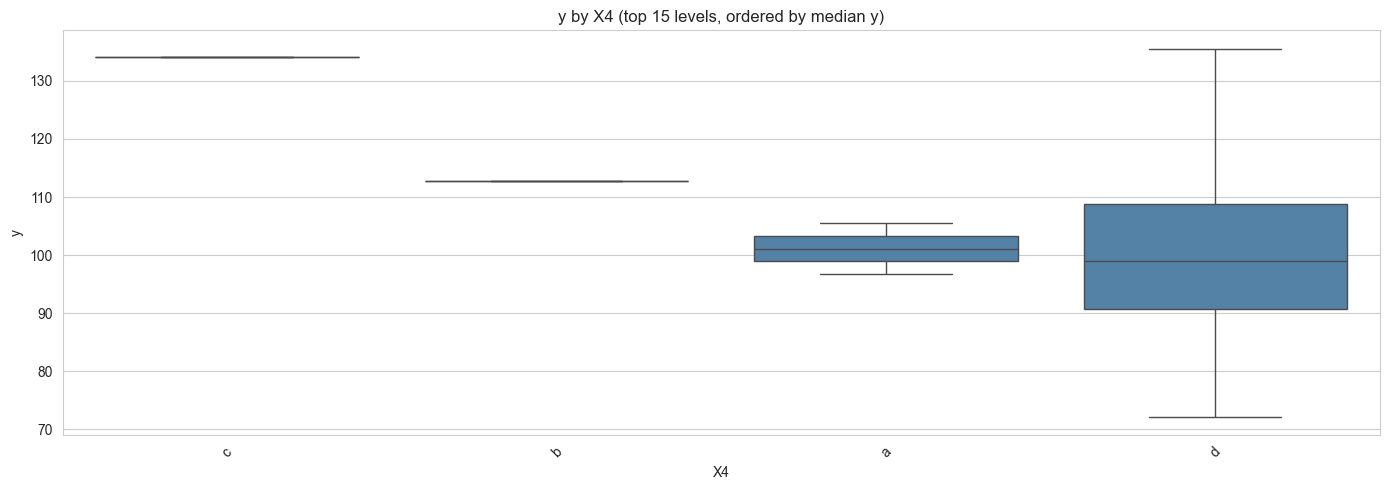

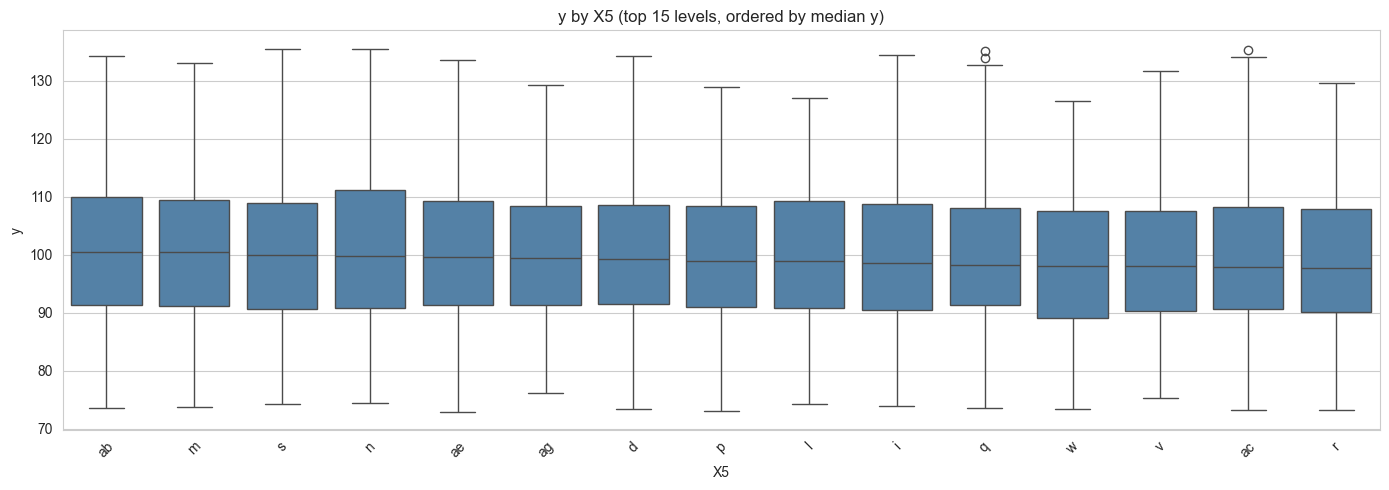

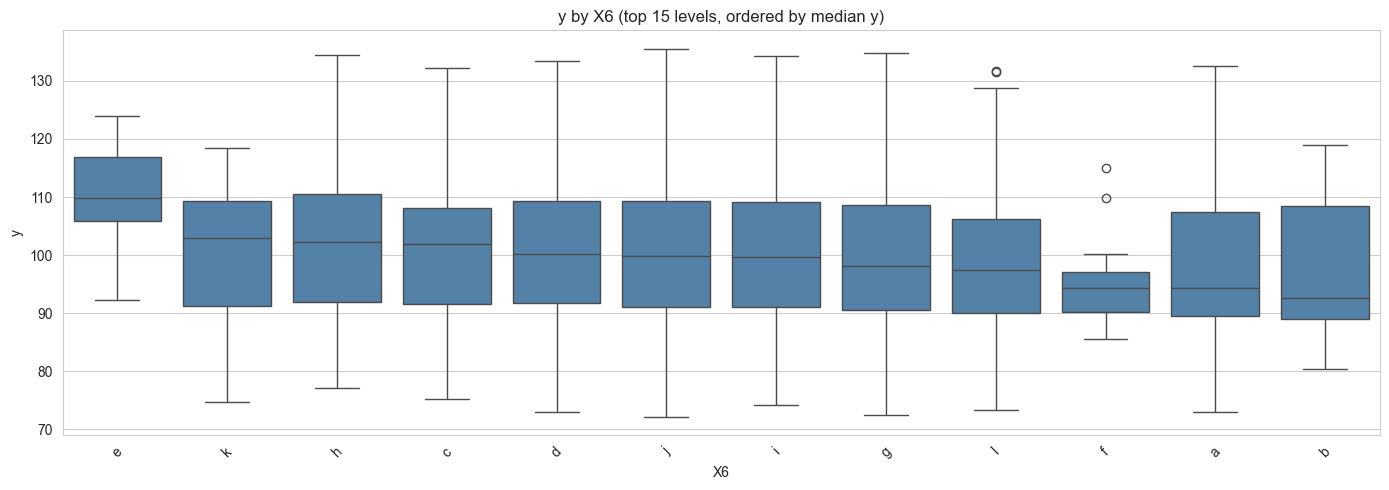

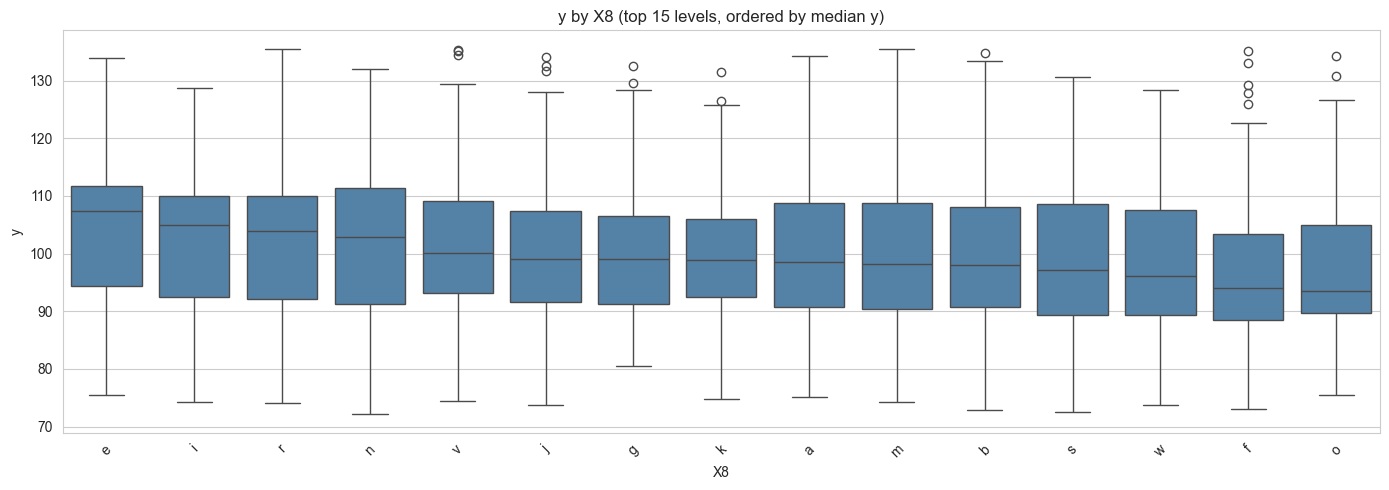

In [27]:
# Boxplots: y by each categorical (top 15 levels by frequency)
for col in cat_cols:
    top_levels = train[col].value_counts().head(15).index
    subset = train[train[col].isin(top_levels)]
    
    plt.figure(figsize=(14, 5))
    order = subset.groupby(col)['y'].median().sort_values(ascending=False).index
    sns.boxplot(data=subset, x=col, y='y', order=order, color='steelblue')
    plt.title(f'y by {col} (top 15 levels, ordered by median y)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [28]:
# ANOVA: Does y differ significantly across levels of each categorical?
for col in cat_cols:
    groups = [group['y'].values for _, group in train.groupby(col)]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'NS'
    print(f'{col}: F={f_stat:.2f}, p={p_val:.4e}  {sig}')

X0: F=166.44, p=0.0000e+00  ***
X1: F=8.02, p=1.4434e-29  ***
X2: F=35.82, p=1.1437e-242  ***
X3: F=37.53, p=1.3898e-44  ***
X4: F=3.36, p=1.7983e-02  *
X5: F=2.01, p=1.2177e-03  **
X6: F=5.09, p=5.7867e-08  ***
X8: F=6.28, p=6.7598e-20  ***


---
## 5. Binary Feature Analysis

The bulk of the features are binary (0/1) flags, likely representing whether a specific process or component is present for a given car configuration.

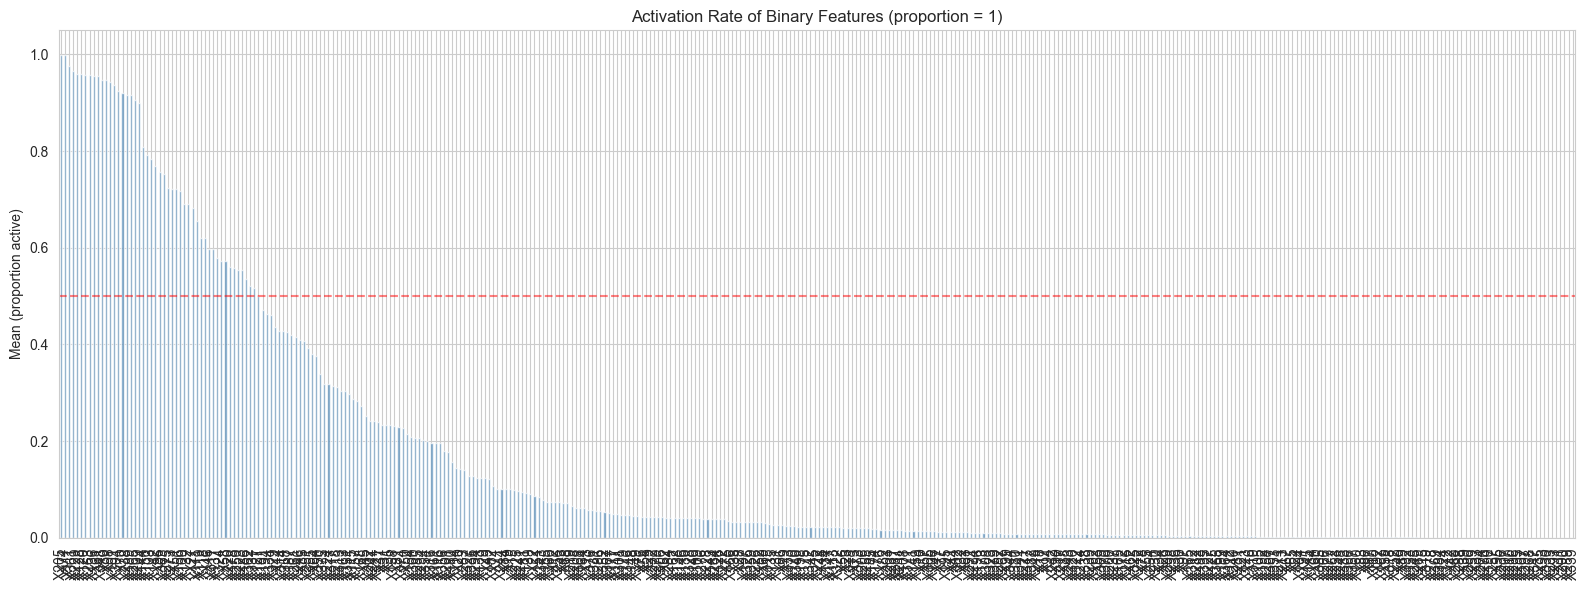

Features always 0 : 13
Features always 1 : 0


In [29]:
# Proportion of 1s in each binary column
binary_means = train[binary_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(16, 6))
binary_means.plot(kind='bar', color='steelblue', alpha=0.7)
plt.title('Activation Rate of Binary Features (proportion = 1)')
plt.ylabel('Mean (proportion active)')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Features always 0 : {(binary_means == 0).sum()}')
print(f'Features always 1 : {(binary_means == 1).sum()}')

In [30]:
# Remove zero-variance binary features (constant columns)
constant_cols = binary_means[(binary_means == 0) | (binary_means == 1)].index.tolist()
print(f'Dropping {len(constant_cols)} constant binary columns: {constant_cols}')

binary_cols_clean = [c for c in binary_cols if c not in constant_cols]

Dropping 13 constant binary columns: ['X107', 'X297', 'X268', 'X347', 'X235', 'X93', 'X330', 'X233', 'X293', 'X11', 'X290', 'X289', 'X339']


In [31]:
# Low-variance filter — features with variance below threshold
# (helps with noise reduction, you can tune the threshold)
selector = VarianceThreshold(threshold=0.01)  # at least ~1% minority class
selector.fit(train[binary_cols_clean])

low_var_mask = ~selector.get_support()
low_var_cols = [binary_cols_clean[i] for i, m in enumerate(low_var_mask) if m]
print(f'Additional low-variance columns (var < 0.01): {len(low_var_cols)}')
print(low_var_cols[:20], '...' if len(low_var_cols) > 20 else '')

Additional low-variance columns (var < 0.01): 135
['X15', 'X16', 'X17', 'X18', 'X21', 'X24', 'X26', 'X30', 'X33', 'X34', 'X36', 'X39', 'X40', 'X42', 'X53', 'X55', 'X59', 'X60', 'X62', 'X65'] ...


In [32]:
# Point-biserial correlation: each binary feature vs y
corr_with_y = []
for col in binary_cols_clean:
    r, p = stats.pointbiserialr(train[col], train['y'])
    corr_with_y.append({'feature': col, 'r': r, 'p_value': p, 'abs_r': abs(r)})

corr_df = pd.DataFrame(corr_with_y).sort_values('abs_r', ascending=False)
print(f'Top 20 binary features correlated with y:\n')
display(corr_df.head(20))

Top 20 binary features correlated with y:



,feature,r,p_value,abs_r
287,X314,0.648697,0.000000e+00,0.648697
240,X261,0.628162,0.000000e+00,0.628162
111,X127,-0.540147,9.145775e-314,0.540147
213,X232,-0.412845,6.319563e-171,0.412845
257,X279,-0.412845,6.319563e-171,0.412845
242,X263,0.412845,6.319563e-171,0.412845
17,X29,-0.412845,6.319563e-171,0.412845
63,X76,-0.408231,8.276890e-167,0.408231
120,X136,0.408231,8.276890e-167,0.408231
42,X54,-0.408231,8.276890e-167,0.408231


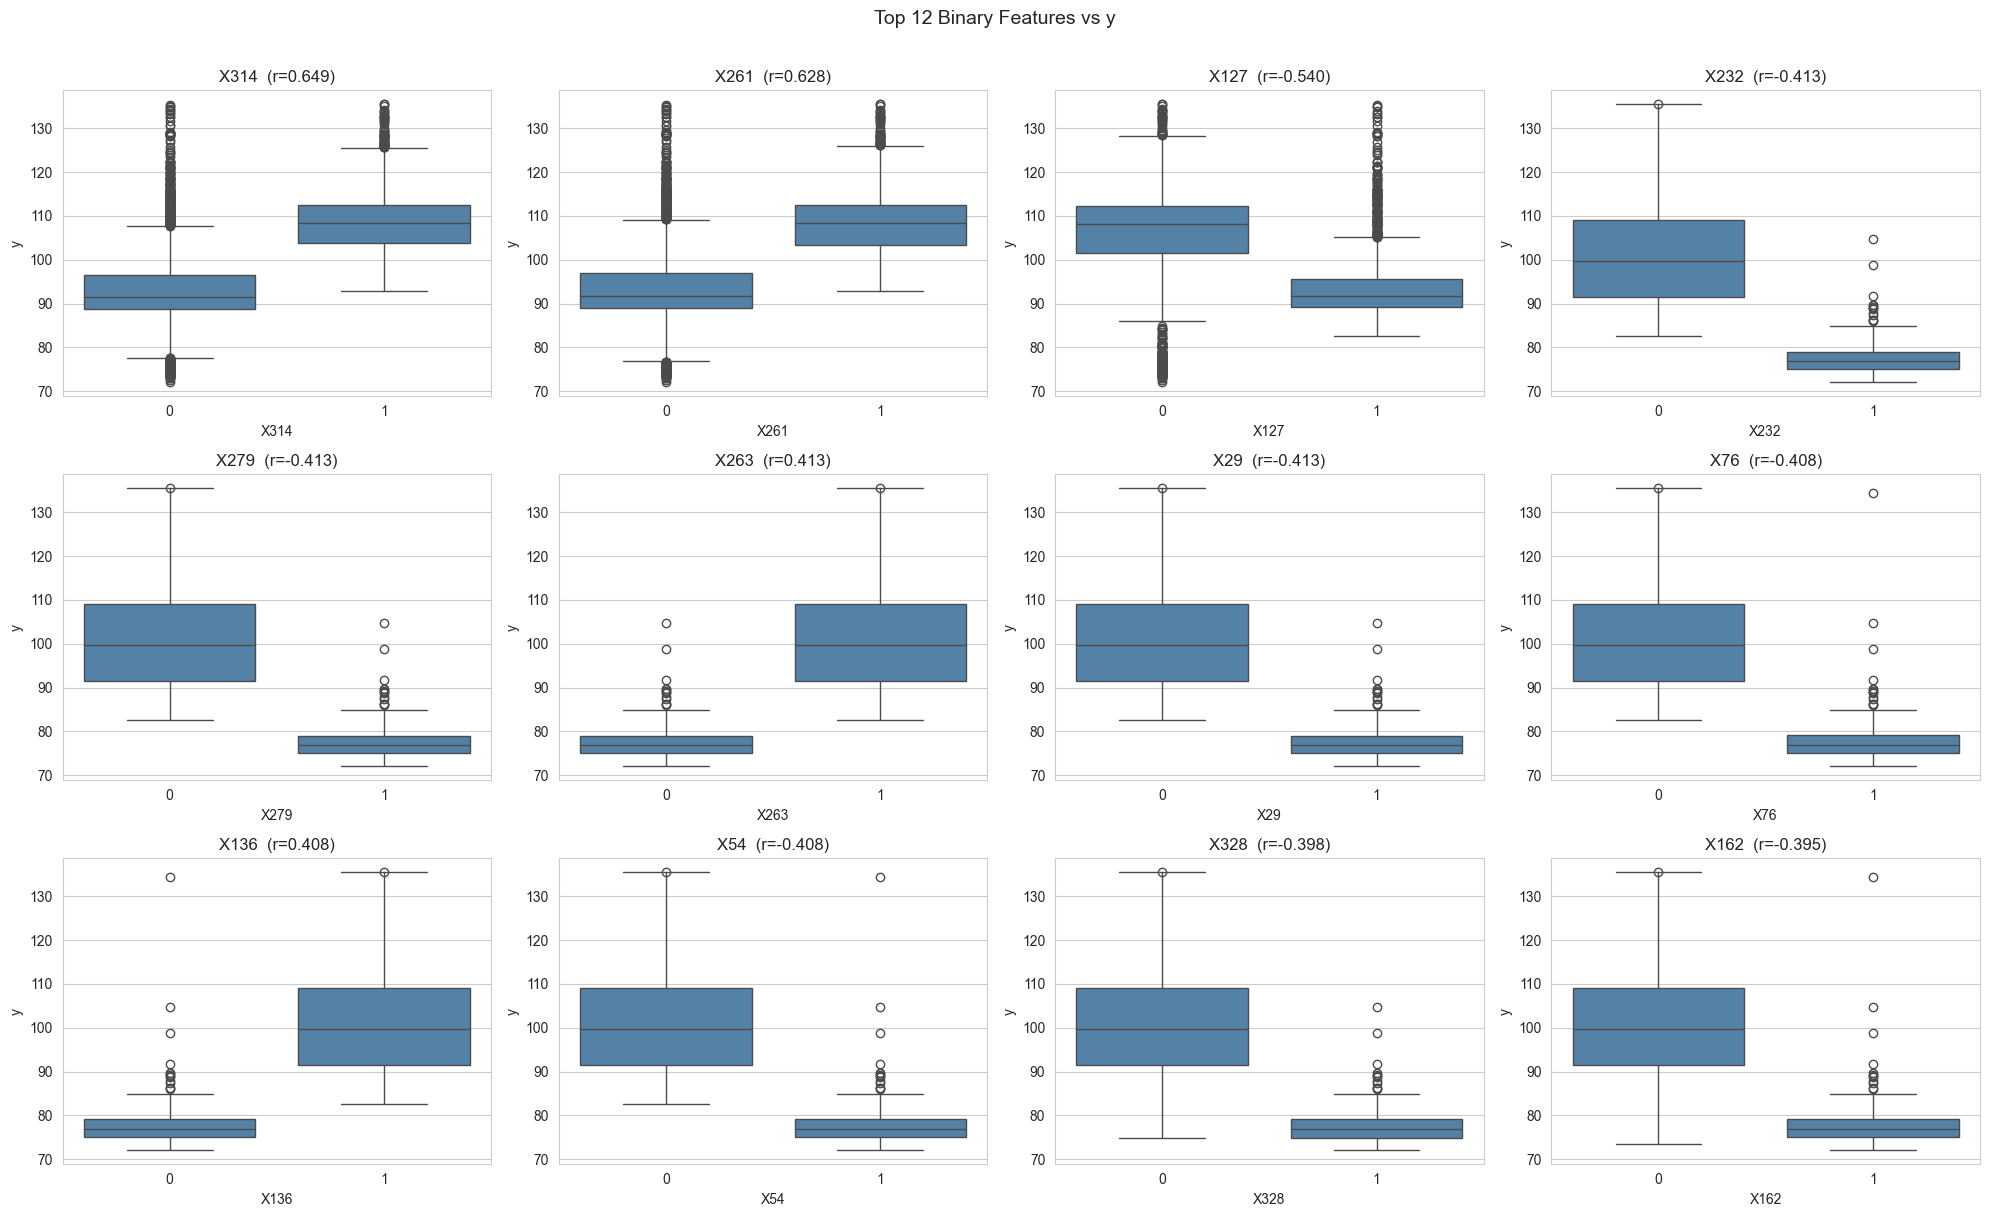

In [33]:
# Visualize top correlated binary features vs y
top_binary = corr_df.head(12)['feature'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flatten(), top_binary):
    sns.boxplot(data=train, x=col, y='y', ax=ax, color='steelblue')
    r_val = corr_df.loc[corr_df['feature'] == col, 'r'].values[0]
    ax.set_title(f'{col}  (r={r_val:.3f})')

plt.suptitle('Top 12 Binary Features vs y', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Correlation (n_active_binary vs y): r=0.1243, p=8.6410e-16


/var/folders/jr/0m1f9xgx6_j43mx32cyrtnpr0000gn/T/ipykernel_45959/1194533631.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['n_active_binary'] = train[binary_cols_clean].sum(axis=1)


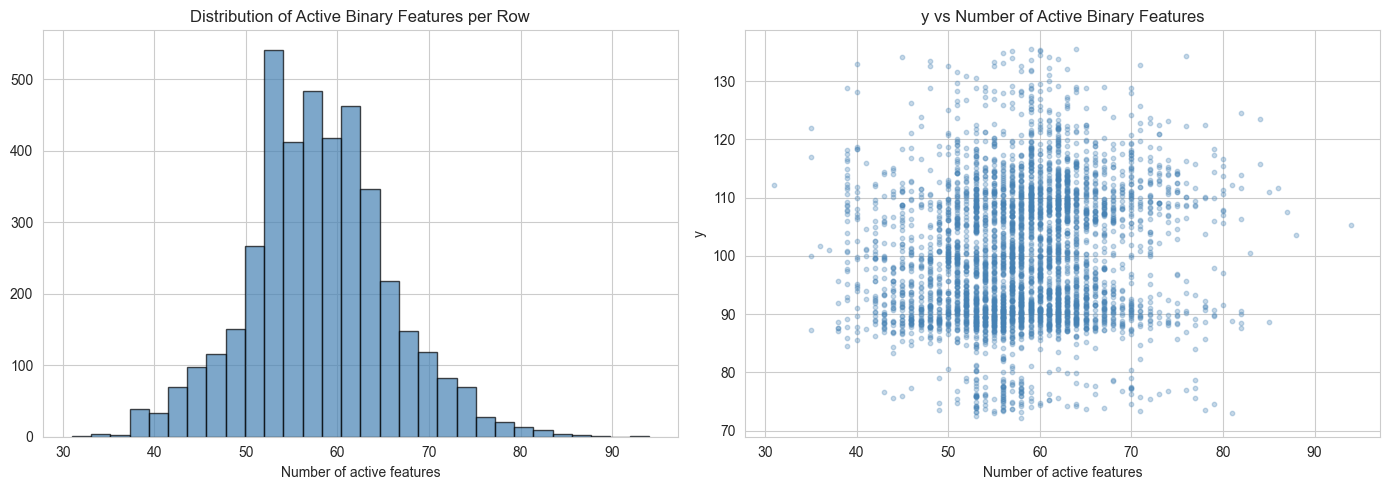

In [34]:
# "Process burden" — how many binary flags are active per row?
train['n_active_binary'] = train[binary_cols_clean].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train['n_active_binary'], bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].set_title('Distribution of Active Binary Features per Row')
axes[0].set_xlabel('Number of active features')

axes[1].scatter(train['n_active_binary'], train['y'], alpha=0.3, s=10, color='steelblue')
axes[1].set_title('y vs Number of Active Binary Features')
axes[1].set_xlabel('Number of active features')
axes[1].set_ylabel('y')

r, p = stats.pearsonr(train['n_active_binary'], train['y'])
print(f'Correlation (n_active_binary vs y): r={r:.4f}, p={p:.4e}')

plt.tight_layout()
plt.show()

---
## 6. Correlation & Multicollinearity

With hundreds of binary features, many may be redundant (identical or near-identical). This matters for model stability and SHAP interpretation.

In [35]:
# Pairwise correlation among binary features
corr_matrix = train[binary_cols_clean].corr()

# Find highly correlated pairs (|r| > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': r
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)
print(f'Highly correlated binary pairs (|r| > 0.9): {len(high_corr_df)}')
display(high_corr_df.head(20))

Highly correlated binary pairs (|r| > 0.9): 221


,feature_1,feature_2,correlation
220,X364,X365,1.0
156,X184,X262,1.0
157,X184,X266,1.0
82,X90,X242,1.0
160,X186,X194,-1.0
79,X90,X94,1.0
78,X89,X245,1.0
77,X88,X320,1.0
75,X88,X243,1.0
72,X88,X122,1.0


In [36]:
# Identify duplicate columns (perfectly correlated or inverse)
# These can safely be removed
to_drop_corr = set()
for _, row in high_corr_df.iterrows():
    if abs(row['correlation']) >= 0.98:
        # Keep the one with higher absolute correlation with y
        r1 = abs(corr_df.loc[corr_df['feature'] == row['feature_1'], 'r'].values)
        r2 = abs(corr_df.loc[corr_df['feature'] == row['feature_2'], 'r'].values)
        r1 = r1[0] if len(r1) > 0 else 0
        r2 = r2[0] if len(r2) > 0 else 0
        drop_col = row['feature_2'] if r1 >= r2 else row['feature_1']
        to_drop_corr.add(drop_col)

print(f'Columns to drop due to near-perfect collinearity: {len(to_drop_corr)}')

Columns to drop due to near-perfect collinearity: 71


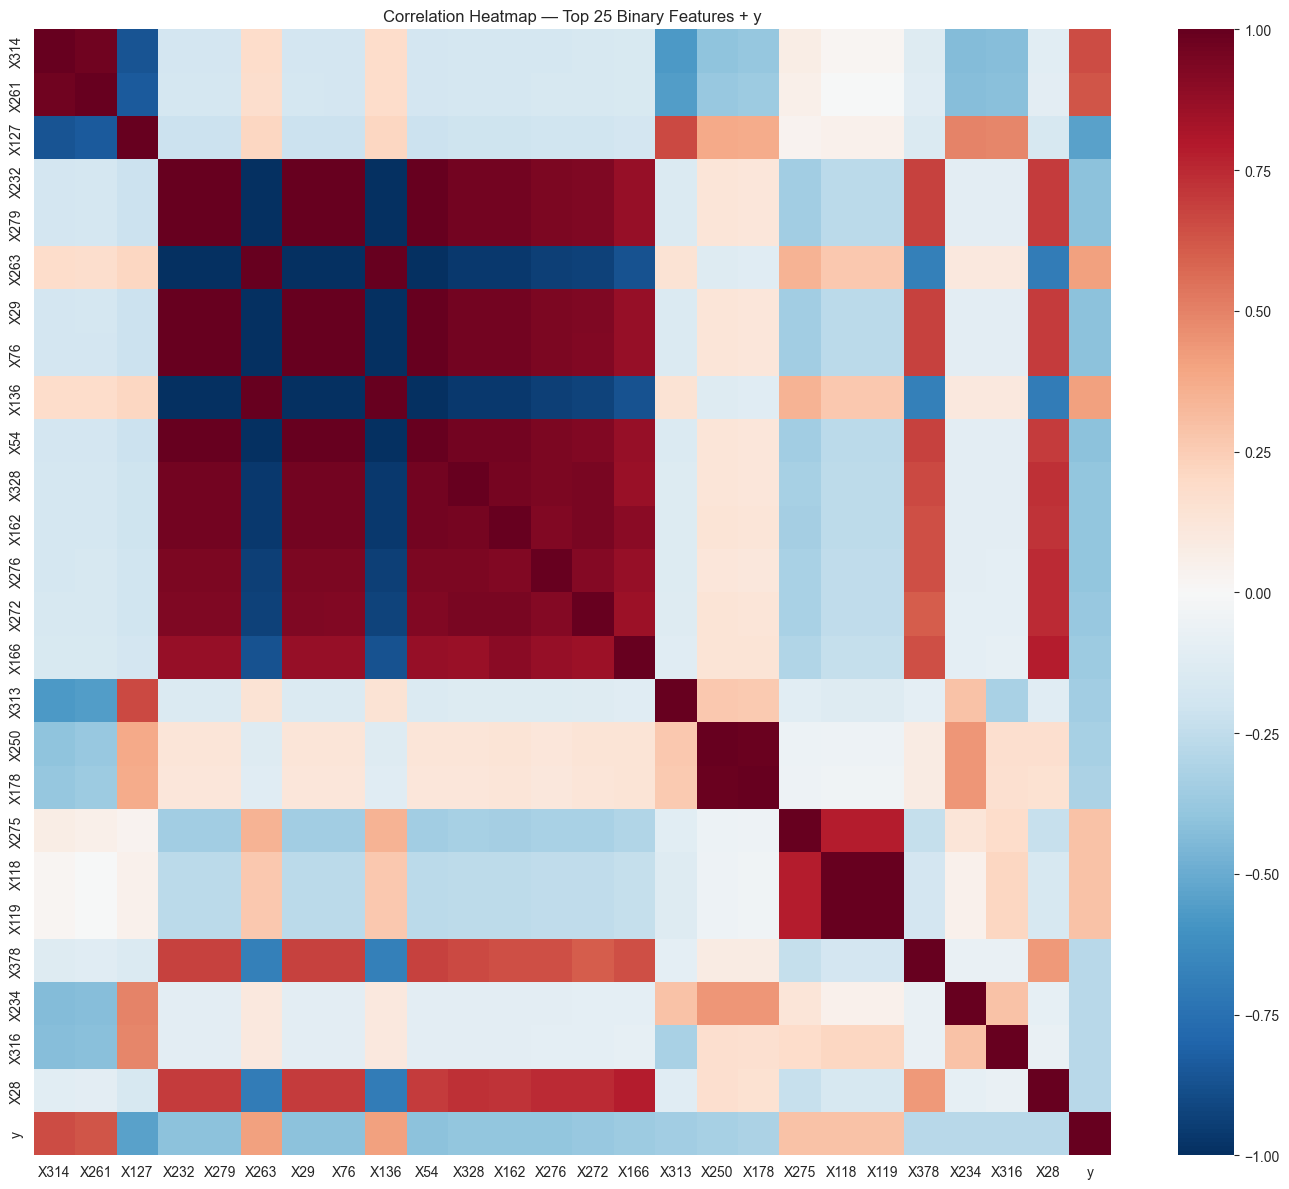

In [37]:
# Heatmap of top-correlated-with-y features
top_features = corr_df.head(25)['feature'].tolist()
sub_corr = train[top_features + ['y']].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(sub_corr, annot=False, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Top 25 Binary Features + y')
plt.tight_layout()
plt.show()

---
## 7. Feature Interactions & Clustering

We explore whether natural groupings of configurations exist that map to different testing time regimes. This can yield richer managerial insights.

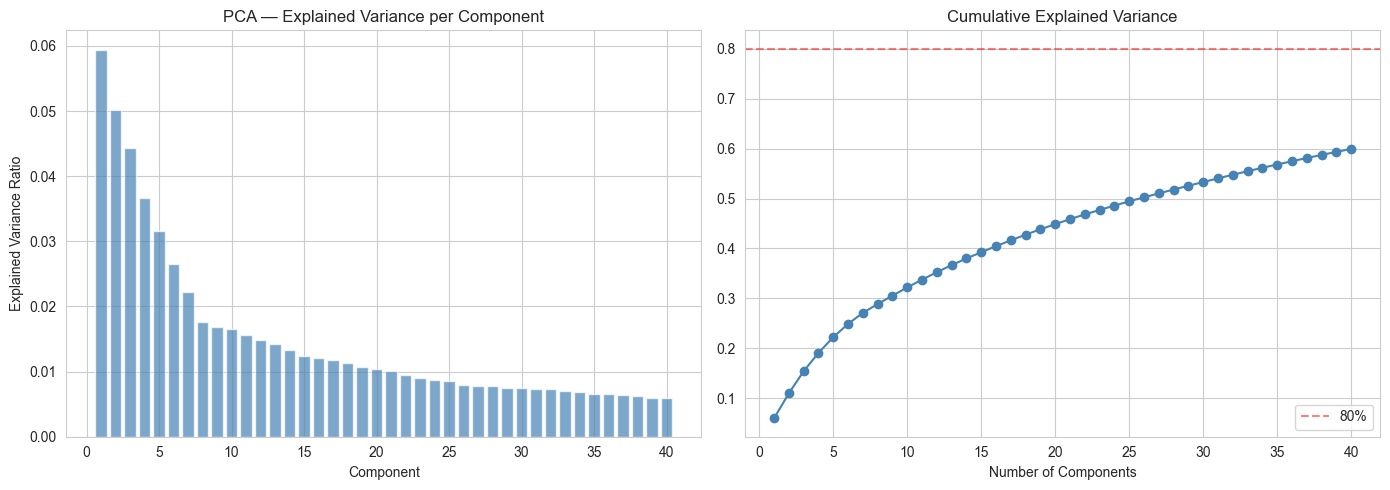

Components for 80% variance: 1


In [45]:
# ── 7a. PCA on binary features ──────────────────────────────────────
# Reduce dimensionality to see if clusters emerge

binary_for_pca = [c for c in binary_cols_clean if c not in to_drop_corr]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(train[binary_for_pca])

pca = PCA(n_components=40, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 41), explained, color='steelblue', alpha=0.7)
axes[0].set_title('PCA — Explained Variance per Component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(range(1, 41), cumulative, 'o-', color='steelblue')
axes[1].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80%')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Components for 80% variance: {np.argmax(cumulative >= 0.8) + 1}')

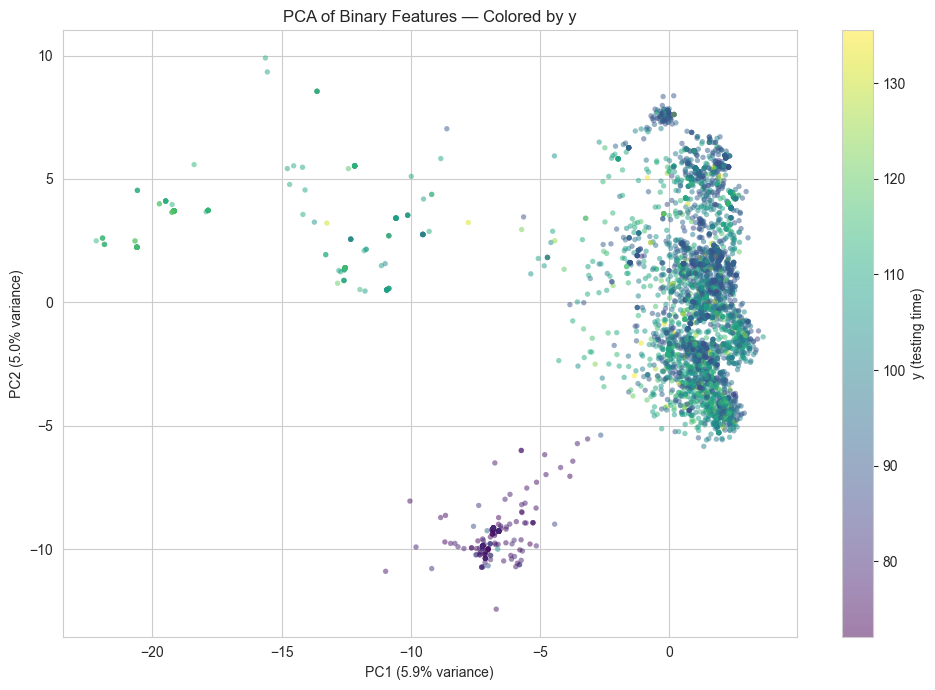

In [46]:
# PCA scatter colored by y
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=train['y'], cmap='viridis',
                      alpha=0.5, s=15, edgecolors='none')
plt.colorbar(scatter, label='y (testing time)')
plt.xlabel(f'PC1 ({explained[0]:.1%} variance)')
plt.ylabel(f'PC2 ({explained[1]:.1%} variance)')
plt.title('PCA of Binary Features — Colored by y')
plt.tight_layout()
plt.show()

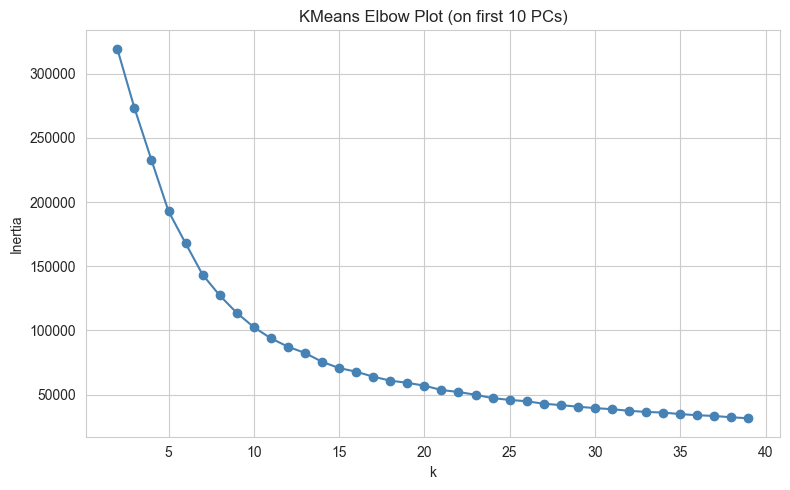

In [50]:
# ── 7b. KMeans Clustering ───────────────────────────────────────────
# Try clustering to see if there are natural "configuration families"

# Elbow method
inertias = []
K_range = range(2, 40)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_pca[:, :10])  # first 10 PCs
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'o-', color='steelblue')
plt.title('KMeans Elbow Plot (on first 10 PCs)')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [51]:
# Pick a k based on the elbow (adjust as needed after viewing the plot)
CHOSEN_K = 7  # ← TUNE THIS after reviewing the elbow plot

km = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=42)
train['cluster'] = km.fit_predict(X_pca[:, :10])

# Cluster sizes
print(train['cluster'].value_counts().sort_index())

cluster
0     670
1     298
2     509
3      91
4     181
5     198
6     505
7      33
8      73
9     406
10    332
11    447
12    366
13     30
14     20
Name: count, dtype: int64


/var/folders/jr/0m1f9xgx6_j43mx32cyrtnpr0000gn/T/ipykernel_45959/756590021.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='cluster', y='y', ax=axes[0], palette='Set2')


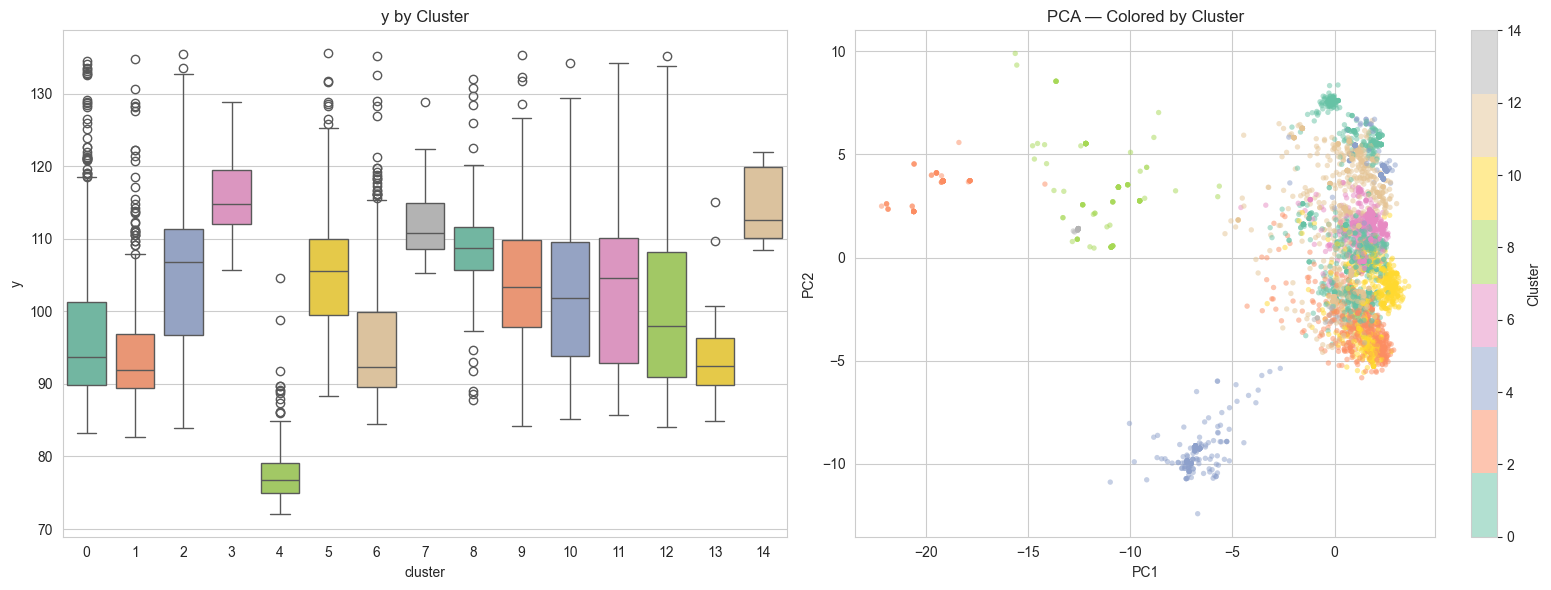

In [52]:
# Cluster vs y distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=train, x='cluster', y='y', ax=axes[0], palette='Set2')
axes[0].set_title('y by Cluster')

# PCA scatter colored by cluster
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=train['cluster'],
                          cmap='Set2', alpha=0.5, s=15, edgecolors='none')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA — Colored by Cluster')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

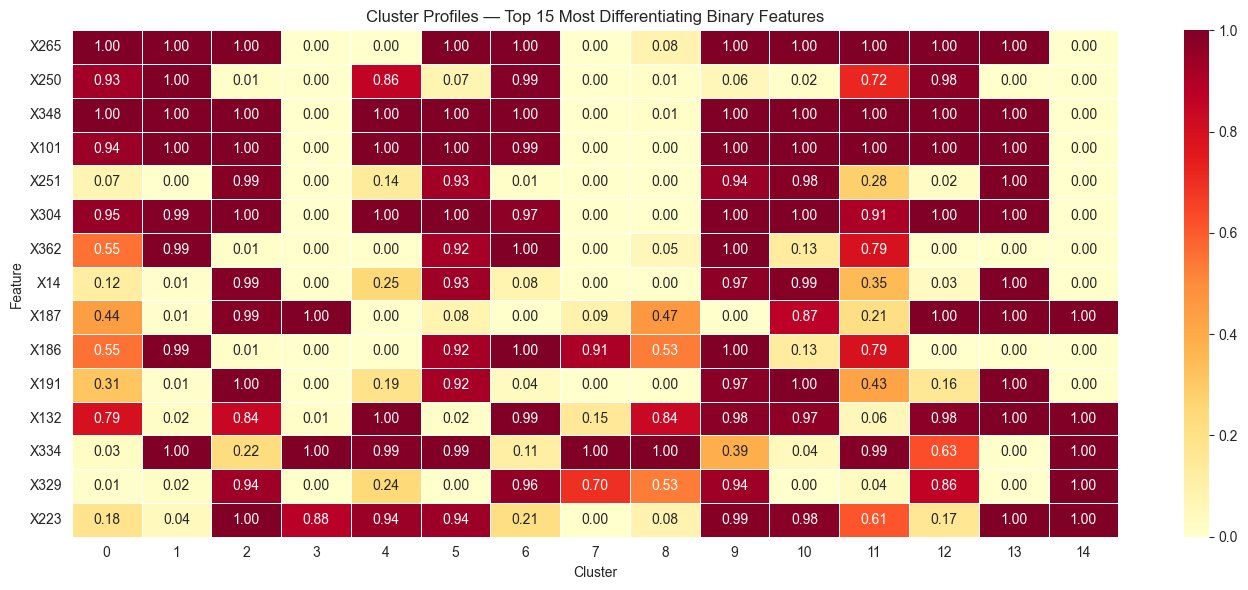

In [53]:
# Cluster profile: mean binary activation per cluster
cluster_profiles = train.groupby('cluster')[binary_for_pca].mean()
cluster_dummies = pd.get_dummies(train['cluster'], prefix='cluster').astype(int)
train = pd.concat([train, cluster_dummies], axis=1)

# Show features that differ most across clusters
feature_variance = cluster_profiles.var(axis=0).sort_values(ascending=False)
top_diff_features = feature_variance.head(15).index.tolist()

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profiles[top_diff_features].T, annot=True, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Profiles — Top 15 Most Differentiating Binary Features')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

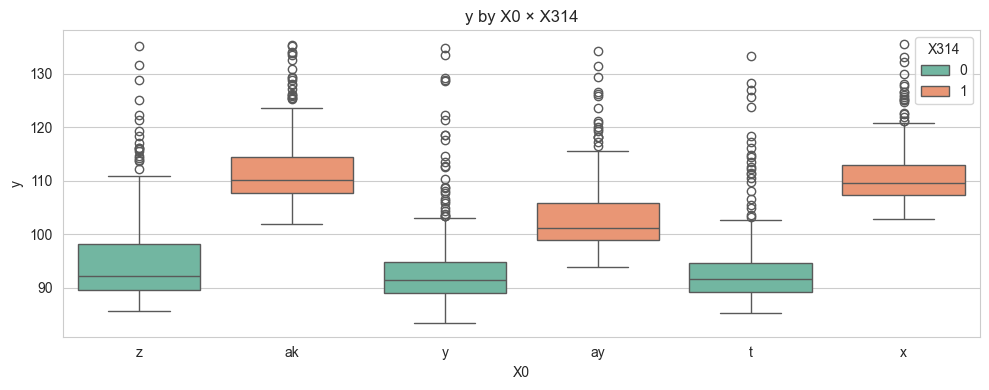

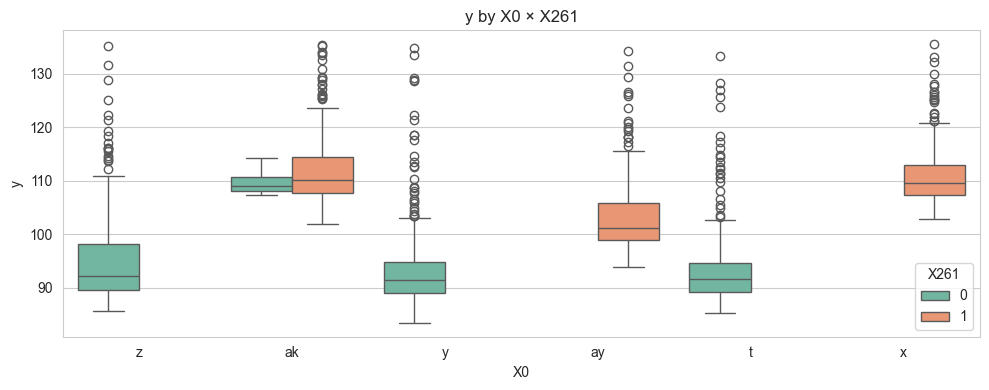

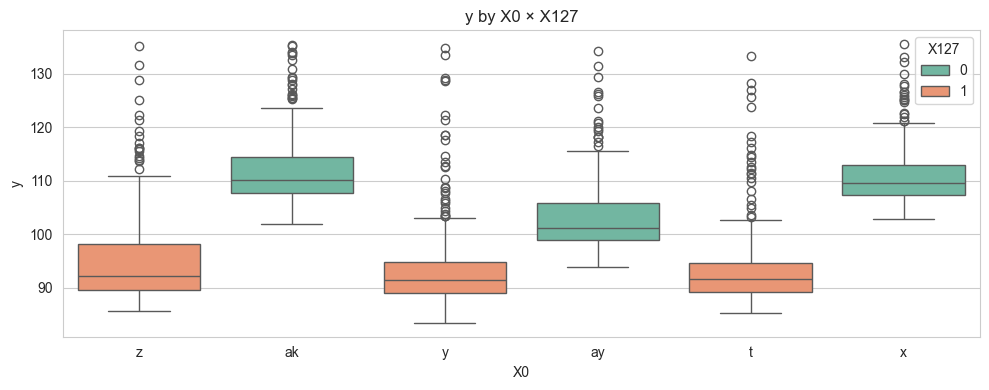

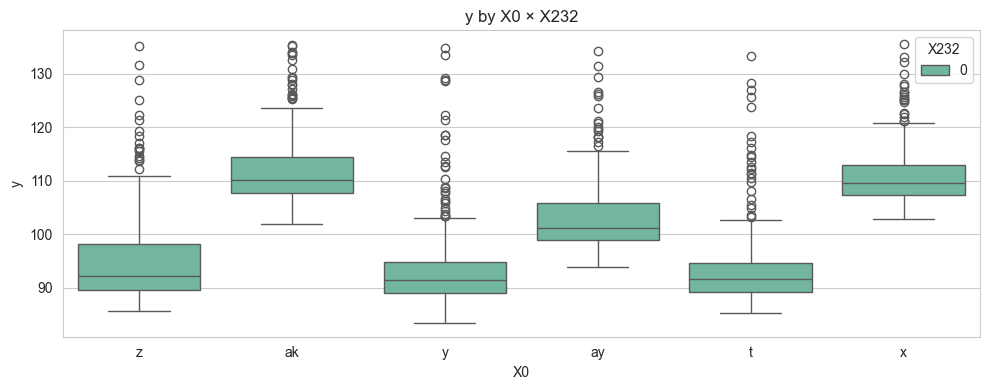

In [54]:
# ── 7c. Categorical × Binary interactions ──────────────────────────
# Do certain categorical levels combined with binary flags yield
# particularly high or low y?

# Example: X0 is usually the most informative categorical
primary_cat = cat_cols[0]  # typically 'X0'
top_levels = train[primary_cat].value_counts().head(6).index

top_bin = corr_df.head(4)['feature'].tolist()

for bf in top_bin:
    subset = train[train[primary_cat].isin(top_levels)]
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=subset, x=primary_cat, y='y', hue=bf,
                order=top_levels, palette='Set2')
    plt.title(f'y by {primary_cat} × {bf}')
    plt.tight_layout()
    plt.show()

---
## 8. One-Hot Encoding & Final Preprocessing

We encode categorical features, apply the cleaning decisions from above, and produce a modeling-ready dataset.

In [55]:
for col in cat_cols:
    known_levels = set(train[col].unique())
    test[col] = test[col].apply(lambda x: x if x in known_levels else 'other')

In [56]:
# ── 8a. Handle unseen test categories ──────────────────────────────
# Combine train + test for consistent encoding, then split back.

train['_is_train'] = 1
test['_is_train']  = 0
if 'y' not in test.columns:
    test['y'] = np.nan  # placeholder

combined = pd.concat([train.drop(columns=['n_active_binary', 'cluster'], errors='ignore'),
                      test], axis=0, ignore_index=True)
print(f'Combined shape: {combined.shape}')

Combined shape: (8368, 379)


/var/folders/jr/0m1f9xgx6_j43mx32cyrtnpr0000gn/T/ipykernel_45959/1060907687.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['_is_train'] = 1
/var/folders/jr/0m1f9xgx6_j43mx32cyrtnpr0000gn/T/ipykernel_45959/1060907687.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['_is_train']  = 0
/var/folders/jr/0m1f9xgx6_j43mx32cyrtnpr0000gn/T/ipykernel_45959/1060907687.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Con

In [57]:
# ── 8b. One-Hot Encode categoricals ────────────────────────────────
combined_ohe = pd.get_dummies(combined, columns=cat_cols, drop_first=False)
print(f'Shape after OHE: {combined_ohe.shape}')

# Preview new columns
new_cols = [c for c in combined_ohe.columns if any(c.startswith(cat + '_') for cat in cat_cols)]
print(f'OHE columns created: {len(new_cols)}')
print(new_cols[:20], '...')

Shape after OHE: (8368, 568)
OHE columns created: 197
['X0_a', 'X0_aa', 'X0_ab', 'X0_ac', 'X0_ad', 'X0_af', 'X0_ai', 'X0_aj', 'X0_ak', 'X0_al', 'X0_am', 'X0_ao', 'X0_ap', 'X0_aq', 'X0_as', 'X0_at', 'X0_au', 'X0_aw', 'X0_ax', 'X0_ay'] ...


In [58]:
# ── 8c. Drop constant and near-duplicate columns ──────────────────
cols_to_drop = list(constant_cols) + list(to_drop_corr) + list(low_var_cols)
cols_to_drop = list(set(cols_to_drop))  # deduplicate in case of overlap
cols_to_drop = [c for c in cols_to_drop if c in combined_ohe.columns]

combined_clean = combined_ohe.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns. New shape: {combined_clean.shape}')

Dropped 84 columns. New shape: (8368, 484)


In [59]:
# ── 8d. Optionally add engineered features ────────────────────────
# Re-compute n_active_binary on the cleaned column set
remaining_binary = [c for c in binary_cols_clean if c not in cols_to_drop
                    and c in combined_clean.columns]
combined_clean['n_active_binary'] = combined_clean[remaining_binary].sum(axis=1)

# You can add cluster labels as a feature too (fit on train PCA, predict on test)
# This is optional — depends on whether it helps your model.
# combined_clean['cluster'] = km.predict(pca.transform(scaler.transform(combined_clean[binary_for_pca])))

print(f'Final combined shape: {combined_clean.shape}')

Final combined shape: (8368, 485)


/var/folders/jr/0m1f9xgx6_j43mx32cyrtnpr0000gn/T/ipykernel_45959/2392977959.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_clean['n_active_binary'] = combined_clean[remaining_binary].sum(axis=1)


In [60]:
# ── 8e. Split back into train / test ──────────────────────────────
train_clean = combined_clean[combined_clean['_is_train'] == 1].drop(columns=['_is_train']).copy()
test_clean  = combined_clean[combined_clean['_is_train'] == 0].drop(columns=['_is_train', 'y']).copy()

print(f'Train clean: {train_clean.shape}')
print(f'Test  clean: {test_clean.shape}')

# Sanity check
assert train_clean['y'].notna().all(), 'Train y has NaN!'
assert train_clean.shape[0] == train.shape[0], 'Row count mismatch!'

Train clean: (4159, 484)
Test  clean: (4209, 483)


In [61]:
# Final feature matrix and target
feature_cols = [c for c in train_clean.columns if c not in ['ID', 'y']]

X_train = train_clean[feature_cols]
y_train = train_clean['y']
X_test  = test_clean[feature_cols]

print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}')

X_train: (4159, 482)
y_train: (4159,)
X_test : (4209, 482)


---
## 9. Export Clean Data for Modeling

In [62]:
# Save processed data
train_clean.to_csv('train_processed.csv', index=False)
test_clean.to_csv('test_processed.csv', index=False)

print('Saved train_processed.csv and test_processed.csv')

Saved train_processed.csv and test_processed.csv


---
## Summary & Next Steps

### Key findings from EDA (fill in after running):
- **Target `y`:** Distribution shape, outliers, skewness → decide on transformations
- **Categorical features:** Which have significant F-statistics; levels that drive high/low y
- **Binary features:** Top correlated with y; constant/redundant columns removed
- **Interactions:** Categorical × binary combinations that stand out
- **Clustering:** Whether natural configuration families exist and how they relate to y

### Next notebook — Modeling:
1. Baseline models (Ridge, Lasso, ElasticNet)
2. Tree-based models (XGBoost, LightGBM)
3. Cross-validation strategy (KFold, 5–10 folds)
4. Hyperparameter tuning
5. **SHAP analysis** on the best model → managerial insights
6. Feature importance comparison across models